## **Data Preprocessing**


<div style="text-align: justify; line-height: 1.65;">Notebook ini melanjutkan pembelajaran setelah Exploratory Data Analysis pada Day 1. Fokus sesi ini adalah mengambil keputusan preprocessing berdasarkan karakteristik data, makna fitur, dan kebutuhan model. Bagian yang memiliki beberapa pilihan menggunakan alur pemeriksaan, perbandingan metode, pemilihan metode, dan treatment final agar peserta dapat melihat alasan di balik keputusan yang digunakan.</div>


<div style="text-align: justify; line-height: 1.65;">Prinsip utama yang digunakan setelah data dibagi adalah <b>fit pada training data, lalu transform validation dan test data</b>. Statistik imputasi, kategori encoder, parameter transformasi, dan parameter scaling hanya dipelajari dari training data agar validation dan test tetap berfungsi sebagai data yang belum digunakan untuk belajar.</div>


## **1. Instalasi Library**


In [1]:
%pip install pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<div style="text-align: justify; line-height: 1.65;">Jika instalasi selesai tanpa pesan error, library utama yang dibutuhkan untuk pengolahan data, visualisasi, pembagian data, imputasi, encoding, dan scaling sudah tersedia. Cell ini hanya perlu dijalankan ketika library tersebut belum terpasang pada environment yang digunakan.</div>


## **2. Import Library**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler

pd.set_option("display.max_columns", None)

COLOR_DARK = "#24465F"
COLOR_PRIMARY = "#4F7896"
COLOR_MID = "#7FA3BC"
COLOR_LIGHT = "#B9CFDE"
COLOR_SOFT = "#E5EEF4"

TRANSFORM_COLORS = {
    "original": COLOR_LIGHT,
    "log1p": COLOR_PRIMARY,
    "square_root": COLOR_MID
}

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.edgecolor": "#AABCC8",
    "axes.spines.top": False,
    "axes.spines.right": False
})


<div style="text-align: justify; line-height: 1.65;">Library yang digunakan sengaja dibatasi pada kebutuhan preprocessing dasar. Struktur ini membuat kode tetap mudah diikuti oleh peserta yang baru mulai mempelajari data science.</div>


## **3. Memuat Dataset**


In [3]:
DATA_URL = "https://raw.githubusercontent.com/clairedible/DataAnalyst_DSMBC/refs/heads/main/credit_risk_dataset.csv"

try:
    df = pd.read_csv(DATA_URL)
except Exception:
    df = pd.read_csv("credit_risk_dataset.csv")

print("Jumlah baris dan kolom:", df.shape)
display(df.head())


Jumlah baris dan kolom: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


<div style="text-align: justify; line-height: 1.65;">Output awal memperlihatkan ukuran dataset dan contoh isi setiap kolom. Dataset terdiri dari fitur numerik dan kategorikal dengan <code>loan_status</code> sebagai target. Tampilan awal juga membantu menemukan nilai yang perlu diperiksa lebih lanjut, misalnya usia yang sangat tinggi atau lama bekerja yang tidak sesuai dengan usia peminjam.</div>


## **4. Pemeriksaan Awal Data**


In [4]:
initial_summary = pd.DataFrame({
    "tipe_data": df.dtypes.astype(str),
    "jumlah_missing": df.isna().sum(),
    "persen_missing": (df.isna().mean() * 100).round(2)
})

print("Jumlah exact duplicate:", df.duplicated().sum())
display(initial_summary)


Jumlah exact duplicate: 165


,tipe_data,jumlah_missing,persen_missing
person_age,int64,0,0.00
person_income,int64,0,0.00
person_home_ownership,str,0,0.00
person_emp_length,float64,895,2.75
loan_intent,str,0,0.00
loan_grade,str,0,0.00
loan_amnt,int64,0,0.00
loan_int_rate,float64,3116,9.56
loan_status,int64,0,0.00
loan_percent_income,float64,0,0.00


<div style="text-align: justify; line-height: 1.65;">Dataset awal memiliki 32.581 baris dan 12 kolom. Terdapat 165 exact duplicate. Missing value hanya muncul pada <code>person_emp_length</code> sebanyak 895 observasi atau 2,75 persen dan <code>loan_int_rate</code> sebanyak 3.116 observasi atau 9,56 persen. Temuan ini menunjukkan bahwa cleaning dapat difokuskan pada duplicate, validasi domain, serta dua fitur yang memang memiliki missing value.</div>


## **5. Data Cleaning dan Domain Validation**


<div style="text-align: justify; line-height: 1.65;">Data cleaning pada bagian ini hanya menangani masalah yang dapat dinilai melalui exact duplicate dan aturan domain yang jelas. Nilai ekstrem secara statistik belum dianggap salah pada tahap ini. Nilai tersebut akan diperiksa kembali pada bagian outlier.</div>


## **5.1 Exact Duplicate**


In [5]:
df_prep = df.copy()

print("Duplicate sebelum cleaning:", df_prep.duplicated().sum())
df_prep = df_prep.drop_duplicates().reset_index(drop=True)
print("Duplicate setelah cleaning:", df_prep.duplicated().sum())
print("Jumlah baris setelah cleaning:", len(df_prep))


Duplicate sebelum cleaning: 165
Duplicate setelah cleaning: 0
Jumlah baris setelah cleaning: 32416


<div style="text-align: justify; line-height: 1.65;">Sebanyak 165 exact duplicate berhasil dihapus. Jumlah baris berubah dari 32.581 menjadi 32.416 dan tidak ada duplicate yang tersisa. Penghapusan dilakukan sebelum split agar record identik tidak tersebar ke subset yang berbeda.</div>


## **5.2 Pemeriksaan Domain Fitur Numerik**


<div style="text-align: justify; line-height: 1.65;">Aturan domain berikut digunakan sebagai asumsi pembelajaran pada dataset ini. Usia di atas 100 tahun diperlakukan sebagai nilai tidak wajar untuk konteks peminjam pada latihan ini. Batas tersebut bukan aturan universal untuk seluruh dataset kredit. Aturan lain menggunakan hubungan logis yang dapat diperiksa langsung dari makna fitur.</div>


In [6]:
invalid_masks = {
    "person_age": (df_prep["person_age"] <= 0) | (df_prep["person_age"] > 100),
    "person_income": df_prep["person_income"] < 0,
    "person_emp_length": df_prep["person_emp_length"] < 0,
    "loan_amnt": df_prep["loan_amnt"] <= 0,
    "loan_int_rate": df_prep["loan_int_rate"] < 0,
    "loan_percent_income": df_prep["loan_percent_income"] < 0,
    "cb_person_cred_hist_length": df_prep["cb_person_cred_hist_length"] < 0
}

invalid_emp_vs_age = (
    df_prep["person_emp_length"].notna()
    & (df_prep["person_emp_length"] > df_prep["person_age"])
)

invalid_credit_vs_age = (
    df_prep["cb_person_cred_hist_length"].notna()
    & (df_prep["cb_person_cred_hist_length"] > df_prep["person_age"])
)

domain_summary = pd.DataFrame({
    "aturan": [
        "person_age <= 0 atau > 100",
        "person_income < 0",
        "person_emp_length < 0",
        "loan_amnt <= 0",
        "loan_int_rate < 0",
        "loan_percent_income < 0",
        "cb_person_cred_hist_length < 0",
        "person_emp_length > person_age",
        "cb_person_cred_hist_length > person_age"
    ],
    "jumlah_invalid": [
        invalid_masks["person_age"].sum(),
        invalid_masks["person_income"].sum(),
        invalid_masks["person_emp_length"].sum(),
        invalid_masks["loan_amnt"].sum(),
        invalid_masks["loan_int_rate"].sum(),
        invalid_masks["loan_percent_income"].sum(),
        invalid_masks["cb_person_cred_hist_length"].sum(),
        invalid_emp_vs_age.sum(),
        invalid_credit_vs_age.sum()
    ]
})

display(domain_summary)


,aturan,jumlah_invalid
0,person_age <= 0 atau > 100,5
1,person_income < 0,0
2,person_emp_length < 0,0
3,loan_amnt <= 0,0
4,loan_int_rate < 0,0
5,loan_percent_income < 0,0
6,cb_person_cred_hist_length < 0,0
7,person_emp_length > person_age,2
8,cb_person_cred_hist_length > person_age,0


<div style="text-align: justify; line-height: 1.65;">Domain validation menemukan 5 nilai usia yang berada di luar asumsi 1 sampai 100 tahun dan 2 nilai lama bekerja yang melebihi usia peminjam. Aturan numerik lainnya tidak menemukan pelanggaran. Hasil ini menunjukkan bahwa nilai ekstrem pada pendapatan, jumlah pinjaman, suku bunga, rasio pinjaman terhadap pendapatan, dan panjang riwayat kredit tidak dapat langsung dianggap invalid hanya dari besar nilainya.</div>


In [7]:
for col, mask in invalid_masks.items():
    df_prep.loc[mask, col] = np.nan

df_prep.loc[invalid_emp_vs_age, "person_emp_length"] = np.nan
df_prep.loc[invalid_credit_vs_age, "cb_person_cred_hist_length"] = np.nan

missing_after_domain = df_prep.isna().sum()
missing_after_domain = missing_after_domain[missing_after_domain > 0].sort_values(ascending=False)

display(missing_after_domain.to_frame("jumlah_missing"))


,jumlah_missing
loan_int_rate,3095
person_emp_length,889
person_age,5


<div style="text-align: justify; line-height: 1.65;">Setelah nilai invalid diubah menjadi missing value, <code>loan_int_rate</code> memiliki 3.095 missing, <code>person_emp_length</code> memiliki 889 missing, dan <code>person_age</code> memiliki 5 missing. Jumlah missing pada dua fitur pertama sedikit turun dibanding kondisi awal setelah exact duplicate dihapus, sedangkan missing pada usia muncul dari domain validation.</div>


## **6. Feature dan Target Separation**


In [8]:
TARGET = "loan_status"
X = df_prep.drop(columns=[TARGET])
y = df_prep[TARGET]

print("Shape feature:", X.shape)
print("Shape target:", y.shape)
display((y.value_counts(normalize=True) * 100).round(2).to_frame("persen"))


Shape feature: (32416, 11)
Shape target: (32416,)


,persen
loan_status,
0,78.13
1,21.87


<div style="text-align: justify; line-height: 1.65;">Setelah cleaning, terdapat 32.416 observasi dengan 11 predictor. Kelas 0 mencakup 78,13 persen data dan kelas 1 mencakup 21,87 persen. Distribusi tersebut menunjukkan ketidakseimbangan kelas, sehingga stratification digunakan saat split agar proporsi target tetap serupa pada setiap subset.</div>


## **7. Train Validation Test Split**


In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

split_target = pd.DataFrame({
    "Train": y_train.value_counts(normalize=True),
    "Validation": y_val.value_counts(normalize=True),
    "Test": y_test.value_counts(normalize=True)
}).T * 100

display(split_target.round(2))


Train: (22691, 11) (22691,)
Validation: (4862, 11) (4862,)
Test: (4863, 11) (4863,)


loan_status,0,1
Train,78.13,21.87
Validation,78.14,21.86
Test,78.12,21.88


<div style="text-align: justify; line-height: 1.65;">Split menghasilkan 22.691 observasi training, 4.862 validation, dan 4.863 test. Proporsi kelas 0 berada pada 78,12 sampai 78,14 persen di seluruh subset, sedangkan kelas 1 berada pada 21,86 sampai 21,88 persen. Selisih yang sangat kecil menunjukkan bahwa stratification berhasil menjaga komposisi target.</div>


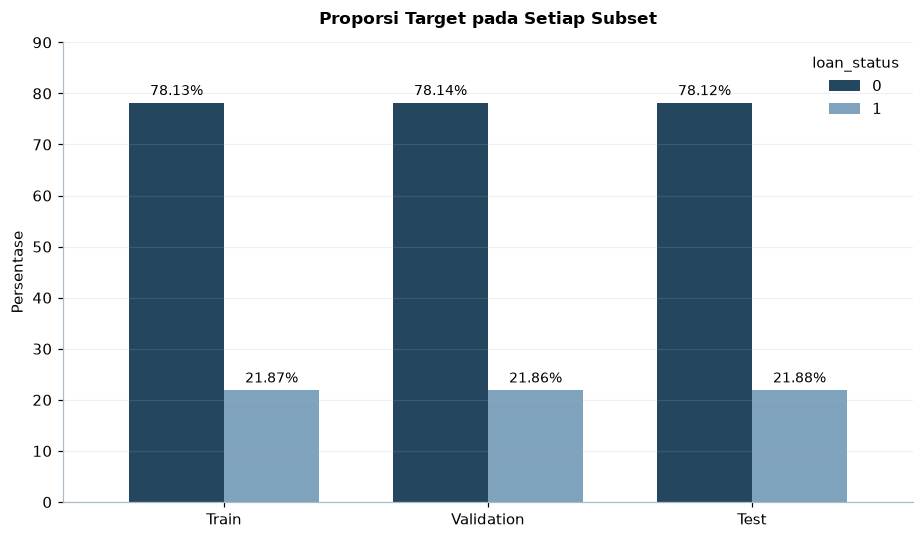

In [10]:
ax = split_target.plot(
    kind="bar",
    figsize=(8.5, 5),
    color=[COLOR_DARK, COLOR_MID],
    width=0.72
)

ax.set_title("Proporsi Target pada Setiap Subset", pad=12, weight="bold")
ax.set_ylabel("Persentase")
ax.set_xlabel("")
ax.set_ylim(0, 90)
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.18)
ax.legend(title="loan_status", frameon=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3, fontsize=9)

plt.tight_layout()
plt.show()


<div style="text-align: justify; line-height: 1.65;">Diagram menunjukkan pola yang hampir identik pada ketiga subset. Kelas 0 tetap berada di sekitar 78 persen dan kelas 1 di sekitar 22 persen pada training, validation, serta test. Visualisasi ini menguatkan hasil tabel bahwa tidak ada subset yang memiliki komposisi target yang menyimpang secara berarti.</div>


In [11]:
X_train_prep = X_train.copy()
X_val_prep = X_val.copy()
X_test_prep = X_test.copy()

print("Salinan preprocessing sudah dibuat untuk train, validation, dan test.")


Salinan preprocessing sudah dibuat untuk train, validation, dan test.


<div style="text-align: justify; line-height: 1.65;">Mulai tahap ini, seluruh keputusan yang memerlukan informasi distribusi dipelajari dari training data. Validation dan test hanya menerima treatment yang sudah ditentukan dari training data. Struktur ini mengurangi risiko data leakage selama preprocessing.</div>


## **8. Outlier Detection dengan Boxplot dan IQR**


<div style="text-align: justify; line-height: 1.65;">Outlier dideteksi sebelum imputasi agar pemeriksaan distribusi masih merepresentasikan data yang belum diisi dengan nilai buatan. Boxplot digunakan sebagai visualisasi, sedangkan IQR digunakan untuk menentukan kandidat outlier. Kandidat tersebut belum otomatis dihapus.</div>


In [12]:
numeric_cols = X_train_prep.select_dtypes(include=np.number).columns.tolist()

outlier_rows = []
for col in numeric_cols:
    series = X_train_prep[col].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((series < lower) | (series > upper)).sum()

    outlier_rows.append({
        "feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "jumlah_kandidat": int(count)
    })

outlier_summary = pd.DataFrame(outlier_rows)
display(outlier_summary.round(3))


,feature,Q1,Q3,IQR,lower_bound,upper_bound,jumlah_kandidat
0,person_age,23.00,30.00,7.00,12.50,40.50,1040
1,person_income,38400.00,79000.00,40600.00,-22500.00,139900.00,1139
2,person_emp_length,2.00,7.00,5.00,-5.50,14.50,578
3,loan_amnt,5000.00,12425.00,7425.00,-6137.50,23562.50,1139
4,loan_int_rate,7.90,13.48,5.58,-0.47,21.85,3
5,loan_percent_income,0.09,0.23,0.14,-0.12,0.44,455
6,cb_person_cred_hist_length,3.00,8.00,5.00,-4.50,15.50,800


<div style="text-align: justify; line-height: 1.65;">IQR menandai kandidat outlier pada seluruh fitur numerik. Jumlah terbanyak muncul pada <code>person_income</code> dan <code>loan_amnt</code>, masing masing 1.139 observasi, kemudian <code>person_age</code> sebanyak 1.040 dan <code>cb_person_cred_hist_length</code> sebanyak 800. <code>loan_int_rate</code> hanya memiliki 3 kandidat. Batas bawah IQR pada beberapa fitur bahkan bernilai negatif, sehingga batas statistik ini tidak tepat digunakan sebagai aturan domain untuk menghapus data.</div>


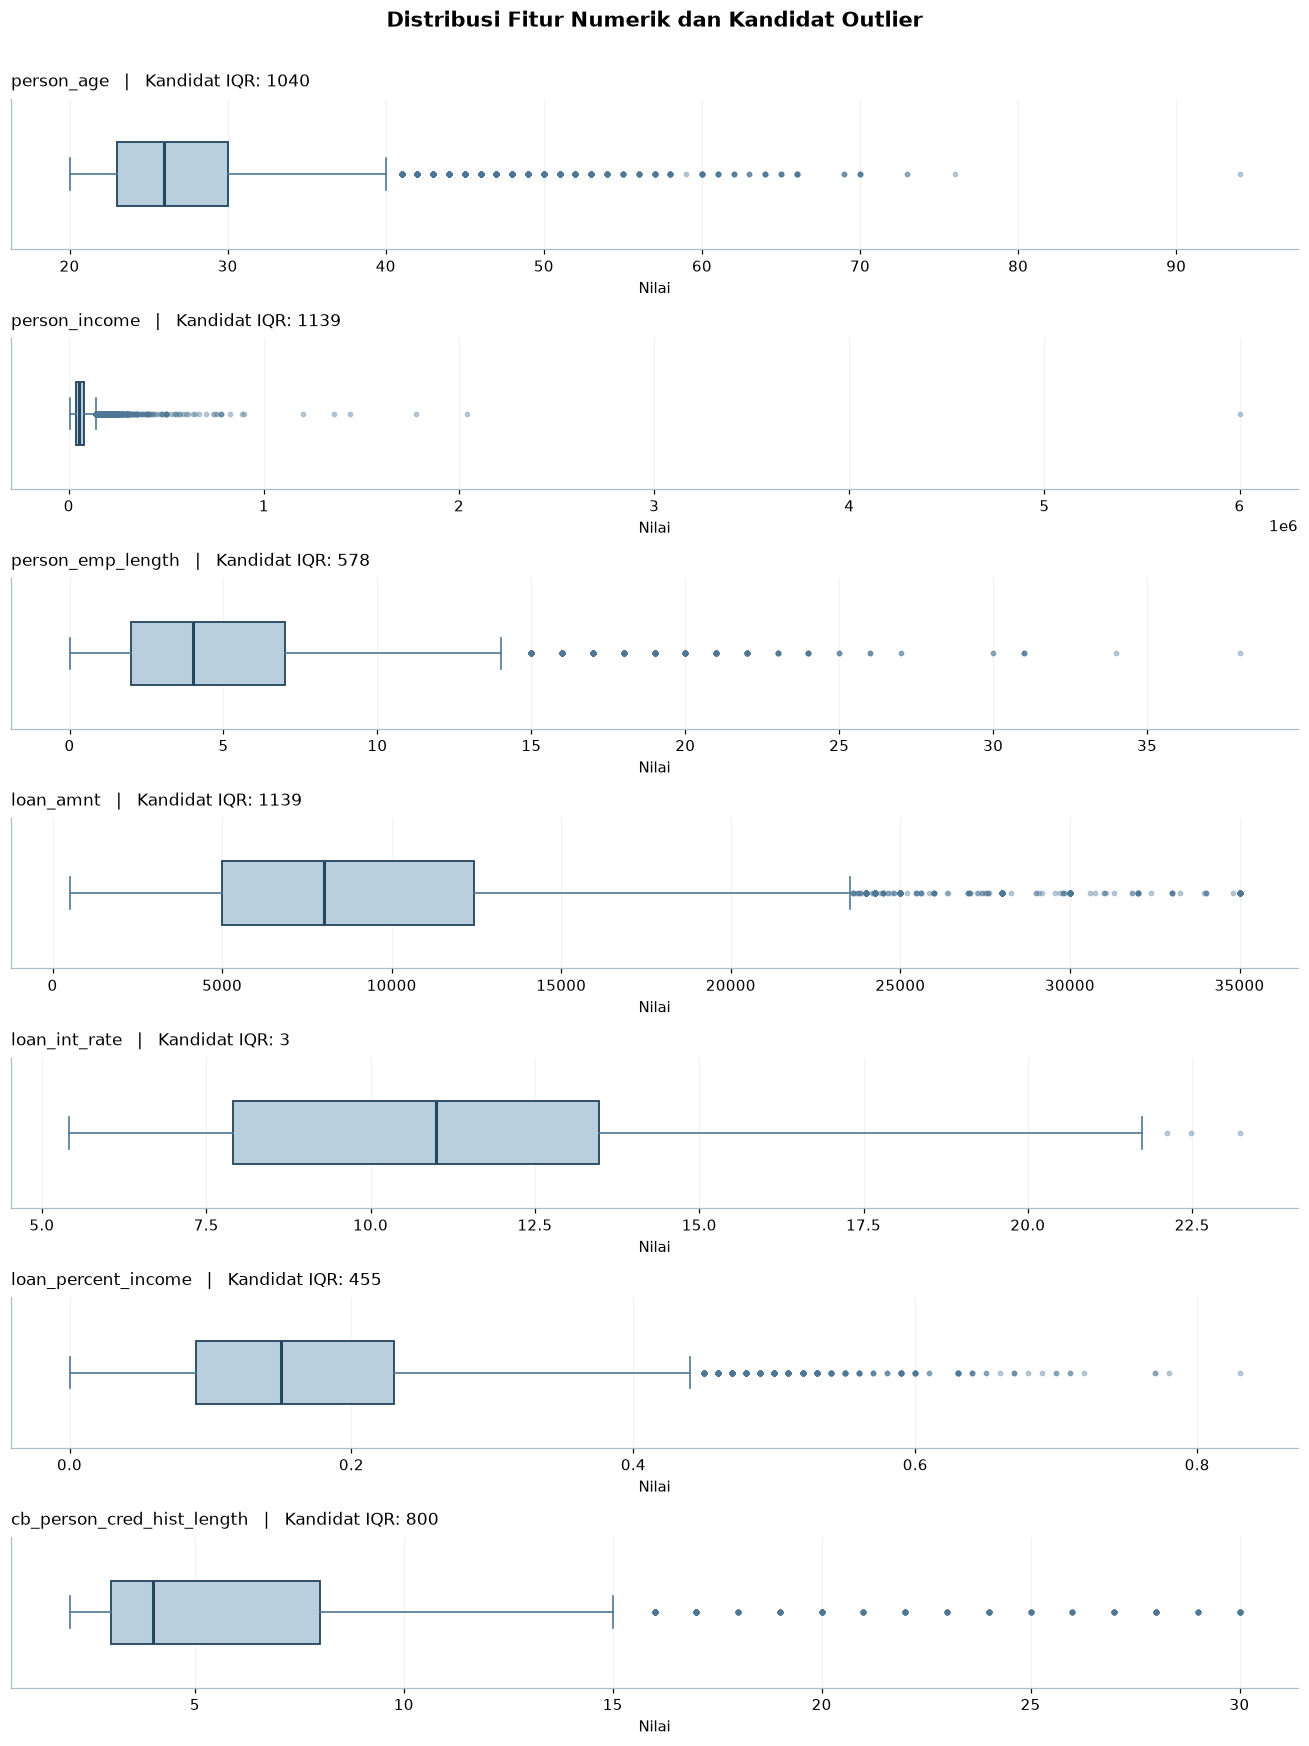

In [13]:
fig, axes = plt.subplots(
    len(numeric_cols),
    1,
    figsize=(12, 2.25 * len(numeric_cols))
)

for ax, col in zip(axes, numeric_cols):
    values = X_train_prep[col].dropna()

    row = outlier_summary.loc[
        outlier_summary["feature"] == col
    ].iloc[0]

    ax.boxplot(
        values,
        orientation="horizontal",
        patch_artist=True,
        widths=0.42,
        boxprops=dict(
            facecolor=COLOR_LIGHT,
            edgecolor=COLOR_DARK,
            linewidth=1.2
        ),
        medianprops=dict(
            color=COLOR_DARK,
            linewidth=2
        ),
        whiskerprops=dict(
            color=COLOR_PRIMARY,
            linewidth=1.1
        ),
        capprops=dict(
            color=COLOR_PRIMARY,
            linewidth=1.1
        ),
        flierprops=dict(
            marker="o",
            markersize=2.8,
            markerfacecolor=COLOR_PRIMARY,
            markeredgecolor=COLOR_PRIMARY,
            alpha=0.35
        )
    )

    ax.set_title(
        f"{col}   |   Kandidat IQR: {int(row['jumlah_kandidat'])}",
        loc="left",
        pad=8
    )
    ax.set_yticks([])
    ax.set_xlabel("Nilai")
    ax.grid(axis="x", alpha=0.16)

fig.suptitle(
    "Distribusi Fitur Numerik dan Kandidat Outlier",
    fontsize=14,
    weight="bold",
    y=1.005
)

plt.tight_layout()
plt.show()


<div style="text-align: justify; line-height: 1.65;">Boxplot memperlihatkan ekor kanan dan titik ekstrem paling jelas pada usia, pendapatan, lama bekerja, jumlah pinjaman, rasio pinjaman terhadap pendapatan, serta panjang riwayat kredit. Pola pada <code>loan_int_rate</code> jauh lebih ringan dan sesuai dengan tabel IQR yang hanya menemukan 3 kandidat. Titik di luar whisker tetap diperlakukan sebagai kandidat statistik dan tidak langsung dihapus.</div>


## **8.1 Pemeriksaan Kandidat Outlier Berdasarkan Domain**


In [14]:
features_to_inspect = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

extreme_examples = []
for col in features_to_inspect:
    top_values = X_train_prep[col].dropna().nlargest(3).tolist()
    extreme_examples.append({
        "feature": col,
        "tiga_nilai_terbesar": top_values
    })

display(pd.DataFrame(extreme_examples))


,feature,tiga_nilai_terbesar
0,person_age,"[94.0, 76.0, 73.0]"
1,person_income,"[6000000.0, 2039784.0, 1782000.0]"
2,person_emp_length,"[38.0, 34.0, 31.0]"
3,loan_amnt,"[35000.0, 35000.0, 35000.0]"
4,loan_int_rate,"[23.22, 22.48, 22.11]"
5,loan_percent_income,"[0.83, 0.78, 0.77]"
6,cb_person_cred_hist_length,"[30.0, 30.0, 30.0]"


<div style="text-align: justify; line-height: 1.65;">Nilai maksimum yang masih tersisa setelah domain validation adalah usia 94 tahun, pendapatan 6.000.000, lama bekerja 38 tahun, jumlah pinjaman 35.000, suku bunga 23,22, rasio pinjaman terhadap pendapatan 0,83, dan panjang riwayat kredit 30 tahun. Nilai tersebut memang ekstrem dibanding mayoritas observasi, tetapi tidak melanggar aturan domain yang sudah ditetapkan. Oleh sebab itu, valid extreme values dipertahankan dan tidak dilakukan capping atau penghapusan otomatis.</div>


## **9. Missing Value Handling**


<div style="text-align: justify; line-height: 1.65;">
Missing value tidak selalu ditangani dengan satu metode yang sama. Pemilihan metode perlu mempertimbangkan tipe fitur, bentuk distribusi, keberadaan nilai ekstrem, serta seberapa sederhana hasil imputasi dapat dijelaskan. Pada bagian ini, beberapa metode dibandingkan terlebih dahulu menggunakan training data. Data utama belum diubah pada tahap perbandingan.
</div>


## **9.1 Pemeriksaan Missing Value pada Training Data**


In [15]:
missing_train = X_train_prep.isna().sum()
missing_train = missing_train[missing_train > 0]

missing_table = pd.DataFrame({
    "jumlah_missing": missing_train,
    "persen_train": (missing_train / len(X_train_prep) * 100).round(2)
})

display(missing_table)


,jumlah_missing,persen_train
person_age,3,0.01
person_emp_length,625,2.75
loan_int_rate,2179,9.60


<div style="text-align: justify; line-height: 1.65;">Training data memiliki 2.179 missing pada <code>loan_int_rate</code> atau 9,60 persen, 625 missing pada <code>person_emp_length</code> atau 2,75 persen, dan 3 missing pada <code>person_age</code> atau 0,01 persen. Menghapus seluruh baris yang memiliki missing akan membuang cukup banyak observasi terutama akibat <code>loan_int_rate</code>, sehingga imputasi dipilih sebagai treatment final.</div>


## **9.2 Metode Imputasi yang Dibandingkan**


<div style="text-align: justify; line-height: 1.65;">
Lima pendekatan digunakan untuk memperlihatkan bahwa nilai yang diisikan ke bagian missing dapat berbeda sesuai metode yang dipilih. Mean, median, mode, dan constant termasuk pendekatan sederhana. KNN Imputer menggunakan informasi dari beberapa fitur numerik untuk mencari observasi yang memiliki pola paling dekat.
</div>

<table style="border-collapse: collapse; width: 100%; margin-top: 12px;">
<tr>
<th style="text-align: left; padding: 7px;">Metode</th>
<th style="text-align: left; padding: 7px;">Konsep</th>
<th style="text-align: left; padding: 7px;">Pertimbangan</th>
</tr>
<tr>
<td style="padding: 7px;">Mean Imputation</td>
<td style="padding: 7px;">Missing diisi dengan rata rata fitur pada training data.</td>
<td style="padding: 7px;">Lebih sesuai ketika distribusi relatif simetris dan tidak didominasi nilai ekstrem.</td>
</tr>
<tr>
<td style="padding: 7px;">Median Imputation</td>
<td style="padding: 7px;">Missing diisi dengan nilai tengah fitur pada training data.</td>
<td style="padding: 7px;">Lebih tahan terhadap distribusi skewed dan nilai ekstrem.</td>
</tr>
<tr>
<td style="padding: 7px;">Mode Imputation</td>
<td style="padding: 7px;">Missing diisi dengan nilai yang paling sering muncul.</td>
<td style="padding: 7px;">Umumnya lebih cocok untuk data kategorikal atau numerik diskrit tertentu.</td>
</tr>
<tr>
<td style="padding: 7px;">Constant Imputation</td>
<td style="padding: 7px;">Missing diisi dengan satu nilai tetap yang ditentukan sebelumnya.</td>
<td style="padding: 7px;">Nilai tetap harus memiliki makna yang jelas. Nilai sembarang dapat membentuk pola buatan.</td>
</tr>
<tr>
<td style="padding: 7px;">KNN Imputer</td>
<td style="padding: 7px;">Missing diperkirakan dari beberapa observasi terdekat berdasarkan fitur numerik lain.</td>
<td style="padding: 7px;">Dapat memanfaatkan hubungan antarfitur, tetapi sensitif terhadap skala dan lebih berat secara komputasi.</td>
</tr>
</table>


## **9.2.1 Mean Imputation**

<div style="text-align: justify; line-height: 1.65;">
Mean merupakan nilai rata rata dari seluruh observasi yang tersedia pada suatu fitur. Nilai mean untuk proses imputasi dihitung hanya dari training data.
</div>

**Rumus Mean**

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i
$$

<div style="text-align: justify; line-height: 1.65;">
Pada rumus tersebut, <i>x̄</i> merupakan nilai mean, <i>x<sub>i</sub></i> merupakan nilai observasi ke i, sedangkan <i>n</i> merupakan jumlah observasi yang tidak missing. Mean dapat bergeser apabila terdapat nilai yang sangat ekstrem. Oleh karena itu, mean lebih sesuai untuk fitur dengan distribusi yang relatif seimbang.
</div>


## **9.2.2 Median Imputation**

<div style="text-align: justify; line-height: 1.65;">
Median merupakan nilai tengah setelah seluruh observasi diurutkan. Separuh observasi berada di bawah median dan separuh lainnya berada di atas median. Median tidak banyak berubah ketika beberapa observasi memiliki nilai yang sangat besar.
</div>

<div style="text-align: justify; line-height: 1.65;">
Metode ini sesuai untuk fitur numerik yang memiliki kemiringan distribusi cukup tinggi atau masih menyimpan valid extreme values.
</div>


## **9.2.3 Mode dan Constant Imputation**

<div style="text-align: justify; line-height: 1.65;">
Mode menggunakan nilai yang paling sering muncul. Metode ini sangat umum pada fitur kategorikal. Pada fitur numerik kontinu, mode belum tentu merepresentasikan pusat distribusi dengan baik.
</div>

<div style="text-align: justify; line-height: 1.65;">
Constant Imputation menggunakan satu nilai tetap. Pada perbandingan ini nilai 0 digunakan hanya untuk memperlihatkan perilaku metode. Nilai 0 tidak otomatis menjadi treatment final. Beberapa fitur pada dataset ini memiliki domain yang tidak sesuai apabila missing diisi 0.
</div>


## **9.2.4 KNN Imputer**

<div style="text-align: justify; line-height: 1.65;">
KNN Imputer tidak mengisi seluruh missing value dengan satu nilai yang sama. Untuk setiap observasi yang memiliki missing value, metode ini mencari sejumlah observasi lain yang memiliki pola numerik paling dekat. Nilai dari tetangga tersebut kemudian digunakan untuk memperkirakan nilai yang hilang.
</div>

**Rumus Sederhana KNN Imputation**

$$
\hat{x}_{ij}
=
\frac{1}{k}
\sum_{r \in N_k(i)} x_{rj}
$$

<div style="text-align: justify; line-height: 1.65;">
Pada rumus tersebut, <i>x̂<sub>ij</sub></i> merupakan nilai hasil imputasi pada observasi ke i untuk fitur ke j. Nilai <i>k</i> menunjukkan jumlah tetangga yang digunakan. Simbol <i>N<sub>k</sub>(i)</i> menunjukkan kumpulan k observasi terdekat dari observasi ke i, sedangkan <i>x<sub>rj</sub></i> merupakan nilai fitur ke j dari setiap tetangga tersebut.
</div>

<div style="text-align: justify; line-height: 1.65;">
KNN menggunakan jarak antarobservasi. Fitur dengan skala yang jauh lebih besar dapat mendominasi perhitungan jarak. Oleh karena itu, data numerik pada tahap perbandingan KNN distandardisasi terlebih dahulu pada copy training data. Standardisasi tersebut hanya digunakan untuk membandingkan metode imputasi dan tidak mengubah pipeline utama.
</div>


## **9.3 Perbandingan Hasil Metode Imputasi**


In [16]:
missing_numeric_cols = [
    col for col in X_train_prep.select_dtypes(include=np.number).columns
    if X_train_prep[col].isna().any()
]

comparison_rows = []

for col in missing_numeric_cols:
    observed = X_train_prep[col].dropna()

    comparison_rows.append({
        "feature": col,
        "missing": int(X_train_prep[col].isna().sum()),
        "skewness": observed.skew(),
        "mean_fill": observed.mean(),
        "median_fill": observed.median(),
        "mode_fill": observed.mode().iloc[0],
        "constant_fill": 0.0
    })

imputation_method_table = pd.DataFrame(comparison_rows)
display(imputation_method_table.round(3))


,feature,missing,skewness,mean_fill,median_fill,mode_fill,constant_fill
0,person_age,3,1.935,27.722,26.00,23.00,0.0
1,person_emp_length,625,1.216,4.767,4.00,0.00,0.0
2,loan_int_rate,2179,0.201,11.021,10.99,10.99,0.0


<div style="text-align: justify; line-height: 1.65;">
Tabel memperlihatkan bahwa mean, median, mode, dan constant dapat menghasilkan nilai pengganti yang berbeda pada fitur yang sama. <code>person_age</code> dan <code>person_emp_length</code> memiliki skewness di atas 1, sehingga jarak antara mean dan median lebih relevan untuk diperhatikan. <code>loan_int_rate</code> memiliki distribusi yang jauh lebih seimbang, sehingga mean dan median berada pada nilai yang relatif berdekatan. Constant bernilai 0 hanya digunakan sebagai pembanding dan tidak dipilih sebagai treatment final.
</div>


In [17]:
numeric_cols_knn = X_train_prep.select_dtypes(include=np.number).columns.tolist()

knn_demo = X_train_prep[numeric_cols_knn].copy()

knn_scaler = StandardScaler()
knn_scaled = pd.DataFrame(
    knn_scaler.fit_transform(knn_demo),
    columns=numeric_cols_knn,
    index=knn_demo.index
)

knn_imputer = KNNImputer(n_neighbors=5)
knn_scaled_imputed = knn_imputer.fit_transform(knn_scaled)

knn_result = pd.DataFrame(
    knn_scaler.inverse_transform(knn_scaled_imputed),
    columns=numeric_cols_knn,
    index=knn_demo.index
)

knn_summary = []

for col in missing_numeric_cols:
    missing_mask = X_train_prep[col].isna()
    knn_values = knn_result.loc[missing_mask, col]

    knn_summary.append({
        "feature": col,
        "jumlah_missing": int(missing_mask.sum()),
        "rata_rata_hasil_knn": knn_values.mean(),
        "median_hasil_knn": knn_values.median(),
        "minimum_hasil_knn": knn_values.min(),
        "maksimum_hasil_knn": knn_values.max()
    })

knn_summary = pd.DataFrame(knn_summary)
display(knn_summary.round(3))


,feature,jumlah_missing,rata_rata_hasil_knn,median_hasil_knn,minimum_hasil_knn,maksimum_hasil_knn
0,person_age,3,34.067,26.200,25.200,50.800
1,person_emp_length,625,4.175,4.000,0.000,20.600
2,loan_int_rate,2179,10.898,10.792,6.656,17.508


<div style="text-align: justify; line-height: 1.65;">
Hasil KNN menunjukkan bahwa nilai imputasi dapat berbeda untuk setiap observasi. Hal ini terlihat dari adanya rentang minimum dan maksimum pada nilai hasil imputasi. Pendekatan ini lebih fleksibel dibanding mean atau median yang mengisi seluruh missing pada satu fitur dengan nilai yang sama. Nilai asli pada bagian missing tidak tersedia. Oleh karena itu, tabel ini tidak digunakan untuk menyatakan bahwa KNN lebih akurat. KNN diperkenalkan untuk menunjukkan metode imputasi yang memanfaatkan kemiripan antarobservasi.
</div>


## **9.4 Perbandingan Distribusi Mean dan Median**


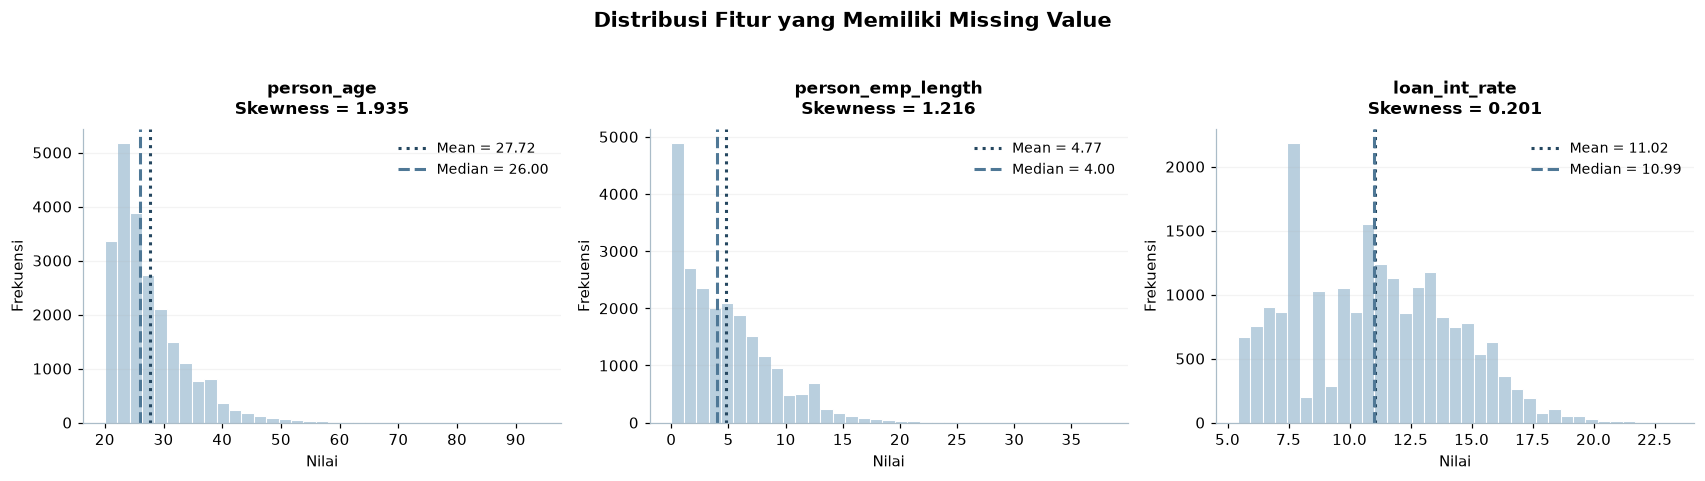

In [18]:
fig, axes = plt.subplots(
    1,
    len(missing_numeric_cols),
    figsize=(5.2 * len(missing_numeric_cols), 4.2)
)

if len(missing_numeric_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, missing_numeric_cols):
    values = X_train_prep[col].dropna()
    mean_value = values.mean()
    median_value = values.median()
    skew_value = values.skew()

    ax.hist(
        values,
        bins=35,
        color=COLOR_LIGHT,
        edgecolor="white",
        linewidth=0.7
    )
    ax.axvline(
        mean_value,
        color=COLOR_DARK,
        linewidth=2,
        linestyle=":",
        label=f"Mean = {mean_value:.2f}"
    )
    ax.axvline(
        median_value,
        color=COLOR_PRIMARY,
        linewidth=2,
        linestyle="--",
        label=f"Median = {median_value:.2f}"
    )

    ax.set_title(
        f"{col}\nSkewness = {skew_value:.3f}",
        pad=10,
        weight="bold"
    )
    ax.set_xlabel("Nilai")
    ax.set_ylabel("Frekuensi")
    ax.grid(axis="y", alpha=0.14)
    ax.legend(frameon=False, fontsize=9)

fig.suptitle(
    "Distribusi Fitur yang Memiliki Missing Value",
    fontsize=14,
    weight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()


<div style="text-align: justify; line-height: 1.65;">Histogram memperlihatkan bahwa distribusi usia dan lama bekerja memiliki ekor kanan yang lebih panjang. Posisi mean pada kedua fitur juga berada di sebelah kanan median, sesuai dengan nilai skewness yang lebih besar dari 1. Distribusi <code>loan_int_rate</code> jauh lebih seimbang dan posisi mean hampir berimpit dengan median. Pola visual tersebut konsisten dengan keputusan median untuk usia dan lama bekerja serta mean untuk suku bunga.</div>


## **9.5 Pemilihan Metode dan Treatment Final**


In [19]:
imputation_comparison = []

for col in missing_numeric_cols:
    skew_value = X_train_prep[col].skew()
    strategy = "median" if abs(skew_value) > 1 else "mean"

    imputation_comparison.append({
        "feature": col,
        "missing": int(X_train_prep[col].isna().sum()),
        "mean": X_train_prep[col].mean(),
        "median": X_train_prep[col].median(),
        "skewness": skew_value,
        "metode_terpilih": strategy
    })

imputation_comparison = pd.DataFrame(imputation_comparison)
display(imputation_comparison.round(3))


,feature,missing,mean,median,skewness,metode_terpilih
0,person_age,3,27.722,26.00,1.935,median
1,person_emp_length,625,4.767,4.00,1.216,median
2,loan_int_rate,2179,11.021,10.99,0.201,mean


<div style="text-align: justify; line-height: 1.65;">
Pemilihan final tetap menggunakan karakteristik distribusi training data. <code>person_age</code> dan <code>person_emp_length</code> memiliki absolute skewness di atas 1, sehingga median dipilih agar imputasi lebih tahan terhadap kemiringan distribusi dan valid extreme values. <code>loan_int_rate</code> memiliki skewness yang relatif rendah serta mean dan median yang berdekatan, sehingga mean dipilih. Mode dan constant tidak dipilih sebab keduanya kurang sesuai untuk karakteristik fitur numerik tersebut. KNN tidak digunakan sebagai treatment final agar baseline preprocessing tetap sederhana, mudah dijelaskan, dan tidak menambah ketergantungan pada perhitungan jarak.
</div>


In [20]:
imputation_plan = dict(
    zip(
        imputation_comparison["feature"],
        imputation_comparison["metode_terpilih"]
    )
)

fitted_imputers = {}

for col, strategy in imputation_plan.items():
    imputer = SimpleImputer(strategy=strategy)

    X_train_prep[[col]] = imputer.fit_transform(X_train_prep[[col]])
    X_val_prep[[col]] = imputer.transform(X_val_prep[[col]])
    X_test_prep[[col]] = imputer.transform(X_test_prep[[col]])

    fitted_imputers[col] = imputer

print("Rencana imputasi:", imputation_plan)
print("Missing train:", int(X_train_prep.isna().sum().sum()))
print("Missing validation:", int(X_val_prep.isna().sum().sum()))
print("Missing test:", int(X_test_prep.isna().sum().sum()))


Rencana imputasi: {'person_age': 'median', 'person_emp_length': 'median', 'loan_int_rate': 'mean'}
Missing train: 0
Missing validation: 0
Missing test: 0


<div style="text-align: justify; line-height: 1.65;">
Treatment final menggunakan median untuk <code>person_age</code> dan <code>person_emp_length</code>, sedangkan <code>loan_int_rate</code> menggunakan mean. Setelah treatment diterapkan, training, validation, dan test tidak lagi memiliki missing value. Nilai mean dan median dipelajari hanya dari training data, kemudian nilai yang sama diterapkan pada validation dan test.
</div>


## **10. Feature Engineering**


<div style="text-align: justify; line-height: 1.65;">
Feature Engineering membentuk representasi baru dari informasi yang sudah tersedia agar hubungan antarfitur lebih mudah digunakan pada tahap modeling. Fitur baru tidak dibuat sebanyak mungkin. Pada notebook ini hanya dua fitur ditambahkan, yaitu <code>interest_burden_proxy</code> dan <code>employment_age_ratio</code>. Keduanya memiliki makna yang dapat dijelaskan dan tidak menduplikasi <code>loan_percent_income</code>.
</div>


## **10.1 Interest Burden Proxy**

<div style="text-align: justify; line-height: 1.65;">
Fitur <code>interest_burden_proxy</code> menggabungkan informasi jumlah pinjaman dan tingkat bunga. Dua peminjam dapat memiliki jumlah pinjaman yang sama, tetapi kombinasi beban pinjaman dan bunganya dapat berbeda apabila tingkat bunganya berbeda.
</div>

**Rumus Feature Engineering**

$$
\text{Interest Burden Proxy}
=
\text{Loan Amount}
\times
\frac{\text{Interest Rate}}{100}
$$

<div style="text-align: justify; line-height: 1.65;">
Pada implementasi kode, rumus tersebut dituliskan sebagai:
</div>

```python
interest_burden_proxy = loan_amnt * (loan_int_rate / 100)
```

<table style="border-collapse: collapse; width: 100%; margin-top: 12px;">
<tr>
<th style="text-align: left; padding: 7px;">Komponen</th>
<th style="text-align: left; padding: 7px;">Makna</th>
</tr>
<tr>
<td style="padding: 7px;"><code>loan_amnt</code></td>
<td style="padding: 7px;">Jumlah pinjaman yang diberikan atau diajukan.</td>
</tr>
<tr>
<td style="padding: 7px;"><code>loan_int_rate</code></td>
<td style="padding: 7px;">Tingkat bunga pinjaman dalam bentuk persen.</td>
</tr>
<tr>
<td style="padding: 7px;"><code>interest_burden_proxy</code></td>
<td style="padding: 7px;">Representasi sederhana dari kombinasi jumlah pinjaman dan tingkat bunga.</td>
</tr>
</table>

<div style="text-align: justify; line-height: 1.65; margin-top: 10px;">
Sebagai contoh, pinjaman sebesar 10.000 dengan tingkat bunga 12 persen menghasilkan <code>interest_burden_proxy</code> sebesar 1.200. Nilai yang lebih besar menunjukkan kombinasi jumlah pinjaman dan tingkat bunga yang lebih tinggi.
</div>

<div style="text-align: justify; line-height: 1.65;">
Fitur ini bukan nilai cicilan dan bukan total bunga aktual. Dataset tidak menyediakan tenor serta skema pembayaran. Oleh karena itu, fitur ini hanya digunakan sebagai proxy untuk merangkum interaksi antara jumlah pinjaman dan tingkat bunga.
</div>


## **10.2 Employment Age Ratio**

<div style="text-align: justify; line-height: 1.65;">
Fitur <code>employment_age_ratio</code> membandingkan lama bekerja dengan usia peminjam. Nilai <code>person_emp_length</code> hanya menunjukkan jumlah tahun bekerja secara absolut. Rasio ini memberikan konteks mengenai lama bekerja apabila dibandingkan dengan usia peminjam.
</div>

**Rumus Feature Engineering**

$$
\text{Employment Age Ratio}
=
\frac{\text{Employment Length}}{\text{Age}}
$$

<div style="text-align: justify; line-height: 1.65;">
Pada implementasi kode, rumus tersebut dituliskan sebagai:
</div>

```python
employment_age_ratio = person_emp_length / person_age
```

<table style="border-collapse: collapse; width: 100%; margin-top: 12px;">
<tr>
<th style="text-align: left; padding: 7px;">Komponen</th>
<th style="text-align: left; padding: 7px;">Makna</th>
</tr>
<tr>
<td style="padding: 7px;"><code>person_emp_length</code></td>
<td style="padding: 7px;">Lama bekerja dalam tahun.</td>
</tr>
<tr>
<td style="padding: 7px;"><code>person_age</code></td>
<td style="padding: 7px;">Usia peminjam dalam tahun.</td>
</tr>
<tr>
<td style="padding: 7px;"><code>employment_age_ratio</code></td>
<td style="padding: 7px;">Proporsi lama bekerja apabila dibandingkan dengan usia peminjam.</td>
</tr>
</table>

<div style="text-align: justify; line-height: 1.65; margin-top: 10px;">
Sebagai contoh, seseorang berusia 30 tahun dengan lama bekerja 6 tahun memiliki <code>employment_age_ratio</code> sebesar 0,20. Seseorang dengan usia yang sama dan lama bekerja 12 tahun memiliki rasio sebesar 0,40. Nilai yang lebih tinggi menunjukkan lama bekerja yang lebih besar relatif terhadap usia.
</div>

<div style="text-align: justify; line-height: 1.65;">
Rasio ini tidak secara langsung menyatakan bahwa seseorang pasti lebih stabil secara finansial. Fitur ini hanya menyediakan representasi relatif antara usia dan lama bekerja agar model dapat memanfaatkan hubungan tersebut apabila memang informatif.
</div>


## **10.3 Pembentukan Fitur Baru**


In [21]:
for split_df in [X_train_prep, X_val_prep, X_test_prep]:
    split_df["interest_burden_proxy"] = (
        split_df["loan_amnt"] * split_df["loan_int_rate"] / 100
    )

    split_df["employment_age_ratio"] = (
        split_df["person_emp_length"] / split_df["person_age"]
    )

fe_summary = X_train_prep[
    ["interest_burden_proxy", "employment_age_ratio"]
].describe().T

display(fe_summary.round(3))
print("Infinity pada fitur baru:", int(np.isinf(X_train_prep[["interest_burden_proxy", "employment_age_ratio"]].to_numpy()).sum()))


,count,mean,std,min,25%,50%,75%,max
interest_burden_proxy,22691.0,1087.511,861.041,48.8,482.480,838.500,1424.000,7087.500
employment_age_ratio,22691.0,0.173,0.133,0.0,0.067,0.148,0.273,0.717


Infinity pada fitur baru: 0


<div style="text-align: justify; line-height: 1.65;">Dua fitur baru terbentuk tanpa menghasilkan infinity. <code>interest_burden_proxy</code> memiliki median 838,5 dan maksimum 7.087,5, sehingga distribusinya masih memiliki nilai tinggi yang cukup jauh dari pusat data. <code>employment_age_ratio</code> memiliki median 0,148 dan maksimum 0,717. Kedua fitur membawa informasi gabungan yang berbeda dari predictor asal dan tidak menduplikasi <code>loan_percent_income</code>.</div>


## **11. Skewness Handling**


<div style="text-align: justify; line-height: 1.65;">Skewness diperiksa pada seluruh fitur numerik training setelah feature engineering. Nilai absolut skewness di atas 1 digunakan sebagai indikator awal distribusi yang cukup miring. Indikator ini tidak langsung menentukan treatment. Setiap kandidat dibandingkan dalam bentuk original, square root, dan log1p terlebih dahulu.</div>


## **11.1 Pemeriksaan Skewness Seluruh Fitur Numerik**


In [22]:
numeric_for_skew = X_train_prep.select_dtypes(include=np.number).columns.tolist()

skew_before = X_train_prep[numeric_for_skew].skew().sort_values(
    key=lambda s: s.abs(),
    ascending=False
)

skew_table = skew_before.to_frame("skewness")
skew_table["abs_skewness"] = skew_table["skewness"].abs()
skew_table["kandidat_transformasi"] = skew_table["abs_skewness"] > 1

display(skew_table.round(3))


,skewness,abs_skewness,kandidat_transformasi
person_income,39.291,39.291,True
person_age,1.936,1.936,True
interest_burden_proxy,1.794,1.794,True
cb_person_cred_hist_length,1.673,1.673,True
person_emp_length,1.247,1.247,True
loan_amnt,1.171,1.171,True
loan_percent_income,1.051,1.051,True
employment_age_ratio,0.587,0.587,False
loan_int_rate,0.211,0.211,False


<div style="text-align: justify; line-height: 1.65;">Tujuh fitur memiliki absolute skewness di atas 1 dan masuk ke tahap perbandingan transformasi. <code>person_income</code> paling ekstrem dengan skewness 39,291. Kandidat lainnya adalah <code>person_age</code> 1,936, <code>interest_burden_proxy</code> 1,794, <code>cb_person_cred_hist_length</code> 1,673, <code>person_emp_length</code> 1,247, <code>loan_amnt</code> 1,171, dan <code>loan_percent_income</code> 1,051. <code>employment_age_ratio</code> serta <code>loan_int_rate</code> tetap menggunakan bentuk original sebab absolute skewness keduanya berada di bawah 1.</div>


## **11.2 Perbandingan Original Square Root dan Log1p**


In [23]:
skew_candidates = skew_table.index[
    skew_table["kandidat_transformasi"]
].tolist()

transform_rows = []

for col in skew_candidates:
    series = X_train_prep[col].dropna()

    methods = {
        "original": series,
        "log1p": np.log1p(series),
        "square_root": np.sqrt(series)
    }

    for method, values in methods.items():
        skew_value = values.skew()

        transform_rows.append({
            "feature": col,
            "method": method,
            "skewness": skew_value,
            "abs_skewness": abs(skew_value)
        })

transform_comparison = pd.DataFrame(transform_rows)

skew_method_table = (
    transform_comparison
    .pivot(index="feature", columns="method", values="skewness")
    [["original", "log1p", "square_root"]]
    .rename(columns={
        "original": "Original",
        "log1p": "Log1p",
        "square_root": "Square Root"
    })
)

display(skew_method_table.round(3))


method,Original,Log1p,Square Root
feature,,,
cb_person_cred_hist_length,1.673,0.489,0.900
interest_burden_proxy,1.794,-0.255,0.746
loan_amnt,1.171,-0.457,0.402
loan_percent_income,1.051,0.804,0.282
person_age,1.936,1.177,1.499
person_emp_length,1.247,-0.485,-0.236
person_income,39.291,0.158,2.980


<div style="text-align: justify; line-height: 1.65;">Perbandingan menunjukkan bahwa tidak ada satu transformasi yang paling sesuai untuk seluruh fitur. Log1p menurunkan skewness <code>person_income</code> dari 39,291 menjadi 0,158, <code>interest_burden_proxy</code> dari 1,794 menjadi minus 0,255, serta <code>cb_person_cred_hist_length</code> dari 1,673 menjadi 0,489. Square root memberi hasil lebih baik pada <code>loan_amnt</code>, <code>loan_percent_income</code>, dan <code>person_emp_length</code>. Pada <code>person_age</code>, log1p memang menurunkan skewness dari 1,936 menjadi 1,177, tetapi nilainya masih di atas batas 1.</div>


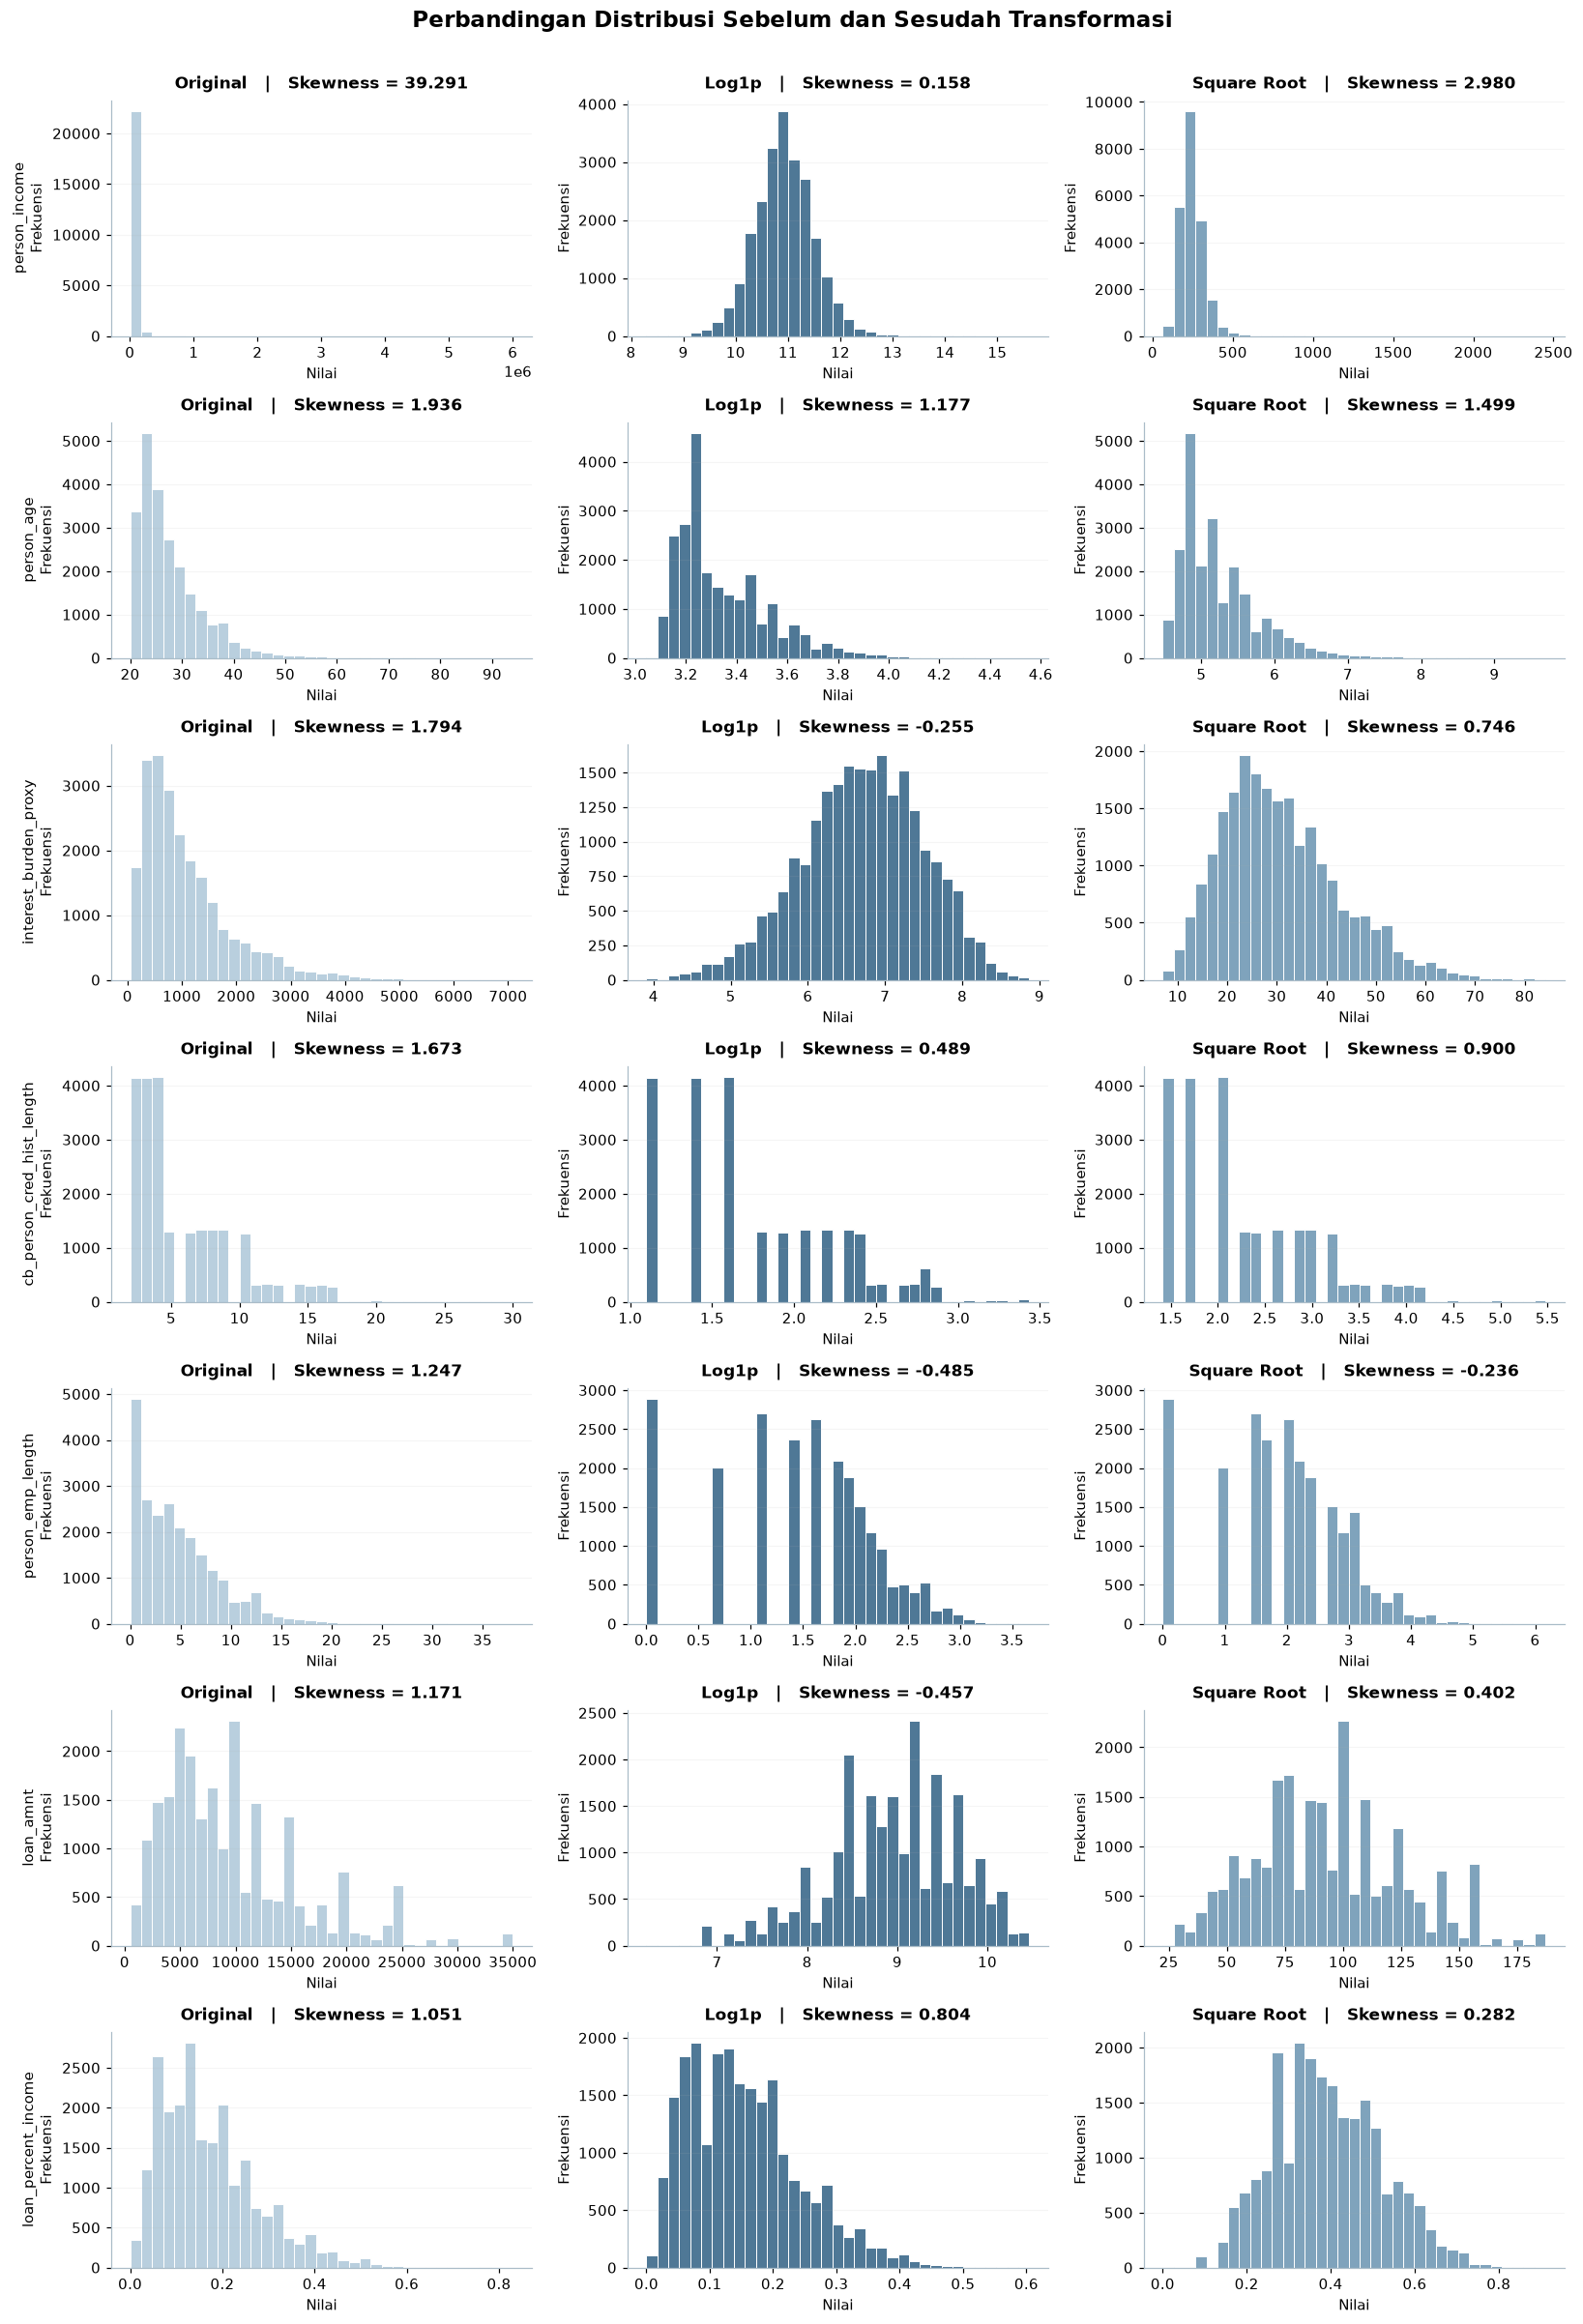

In [24]:
method_order = ["original", "log1p", "square_root"]
method_labels = {
    "original": "Original",
    "log1p": "Log1p",
    "square_root": "Square Root"
}

fig, axes = plt.subplots(
    len(skew_candidates),
    3,
    figsize=(15, 3.1 * len(skew_candidates))
)

if len(skew_candidates) == 1:
    axes = np.array([axes])

for row_idx, col in enumerate(skew_candidates):
    original_values = X_train_prep[col].dropna()

    values_by_method = {
        "original": original_values,
        "log1p": np.log1p(original_values),
        "square_root": np.sqrt(original_values)
    }

    for col_idx, method in enumerate(method_order):
        ax = axes[row_idx, col_idx]
        values = values_by_method[method]
        skew_value = values.skew()

        ax.hist(
            values,
            bins=35,
            color=TRANSFORM_COLORS[method],
            edgecolor="white",
            linewidth=0.65
        )

        ax.set_title(
            f"{method_labels[method]}   |   Skewness = {skew_value:.3f}",
            pad=8,
            weight="bold"
        )
        ax.set_xlabel("Nilai")
        ax.grid(axis="y", alpha=0.12)

        if col_idx == 0:
            ax.set_ylabel(f"{col}\nFrekuensi")
        else:
            ax.set_ylabel("Frekuensi")

fig.suptitle(
    "Perbandingan Distribusi Sebelum dan Sesudah Transformasi",
    fontsize=15,
    weight="bold",
    y=1.005
)

plt.tight_layout()
plt.show()


<div style="text-align: justify; line-height: 1.65;">Setiap baris memperlihatkan satu fitur yang sama dalam tiga bentuk, yaitu original, log1p, dan square root. Perubahan bentuk paling jelas terlihat pada <code>person_income</code>, yang menjadi jauh lebih seimbang setelah log1p. <code>loan_amnt</code>, <code>loan_percent_income</code>, dan <code>person_emp_length</code> terlihat lebih seimbang setelah square root. Namun, distribusi <code>person_age</code> tetap memiliki ekor kanan pada kedua transformasi, sesuai dengan nilai skewness yang masih lebih dari 1.</div>


## **11.3 Pemilihan dan Treatment Final Transformasi**


In [25]:
decision_rows = []

for col in skew_candidates:
    feature_result = transform_comparison[
        transform_comparison["feature"] == col
    ].copy()

    original_row = feature_result[
        feature_result["method"] == "original"
    ].iloc[0]

    transformed_result = feature_result[
        feature_result["method"] != "original"
    ]

    best_transform = transformed_result.loc[
        transformed_result["abs_skewness"].idxmin()
    ]

    if best_transform["abs_skewness"] < 1:
        final_method = best_transform["method"]
        final_skewness = best_transform["skewness"]
    else:
        final_method = "original"
        final_skewness = original_row["skewness"]

    decision_rows.append({
        "feature": col,
        "skewness_awal": original_row["skewness"],
        "metode_final": final_method,
        "skewness_final": final_skewness
    })

transform_decision = pd.DataFrame(decision_rows)

selected_transforms = {
    row["feature"]: row["metode_final"]
    for _, row in transform_decision.iterrows()
    if row["metode_final"] != "original"
}

display(transform_decision.round(3))
print("Transformasi final:", selected_transforms)


,feature,skewness_awal,metode_final,skewness_final
0,person_income,39.291,log1p,0.158
1,person_age,1.936,original,1.936
2,interest_burden_proxy,1.794,log1p,-0.255
3,cb_person_cred_hist_length,1.673,log1p,0.489
4,person_emp_length,1.247,square_root,-0.236
5,loan_amnt,1.171,square_root,0.402
6,loan_percent_income,1.051,square_root,0.282


Transformasi final: {'person_income': 'log1p', 'interest_burden_proxy': 'log1p', 'cb_person_cred_hist_length': 'log1p', 'person_emp_length': 'square_root', 'loan_amnt': 'square_root', 'loan_percent_income': 'square_root'}


<div style="text-align: justify; line-height: 1.65;">Metode final dipilih apabila transformasi mampu membawa absolute skewness ke bawah 1. Log1p dipilih untuk <code>person_income</code>, <code>interest_burden_proxy</code>, dan <code>cb_person_cred_hist_length</code>. Square root dipilih untuk <code>loan_amnt</code>, <code>loan_percent_income</code>, dan <code>person_emp_length</code>. <code>person_age</code> tetap menggunakan bentuk original sebab log1p maupun square root belum menurunkan absolute skewness ke bawah 1. Keputusan ini juga mempertahankan interpretasi usia dalam satuan tahun.</div>


In [26]:
X_train_before_transform = X_train_prep.copy()

for col, method in selected_transforms.items():
    if method == "square_root":
        X_train_prep[col] = np.sqrt(X_train_prep[col])
        X_val_prep[col] = np.sqrt(X_val_prep[col])
        X_test_prep[col] = np.sqrt(X_test_prep[col])

    elif method == "log1p":
        X_train_prep[col] = np.log1p(X_train_prep[col])
        X_val_prep[col] = np.log1p(X_val_prep[col])
        X_test_prep[col] = np.log1p(X_test_prep[col])

final_skew_summary = transform_decision[
    ["feature", "skewness_awal", "metode_final", "skewness_final"]
].copy()

display(final_skew_summary.round(3))


,feature,skewness_awal,metode_final,skewness_final
0,person_income,39.291,log1p,0.158
1,person_age,1.936,original,1.936
2,interest_burden_proxy,1.794,log1p,-0.255
3,cb_person_cred_hist_length,1.673,log1p,0.489
4,person_emp_length,1.247,square_root,-0.236
5,loan_amnt,1.171,square_root,0.402
6,loan_percent_income,1.051,square_root,0.282


<div style="text-align: justify; line-height: 1.65;">Ringkasan final memperlihatkan bahwa enam fitur memperoleh distribusi yang lebih seimbang setelah transformasi terpilih. <code>person_age</code> tetap memiliki skewness 1,936 dan sengaja tidak ditransformasi. Nilai tersebut akan tetap ditangani secara aman pada tahap scaling menggunakan metode yang lebih tahan terhadap extreme values.</div>


## **12. Categorical Encoding**


<div style="text-align: justify; line-height: 1.65;">Encoding dipilih berdasarkan makna kategori. Fitur biner cukup direpresentasikan dengan dua nilai. Fitur ordinal mempertahankan urutan kategorinya. Fitur nominal tidak memiliki urutan alami, sehingga One Hot Encoding digunakan agar model tidak membaca urutan yang sebenarnya tidak ada.</div>


## **12.1 Pemeriksaan Kategori**


In [27]:
categorical_cols = X_train_prep.select_dtypes(exclude=np.number).columns.tolist()

category_summary = []
for col in categorical_cols:
    category_summary.append({
        "feature": col,
        "jumlah_kategori": X_train_prep[col].nunique(),
        "kategori_train": sorted(X_train_prep[col].dropna().unique().tolist())
    })

display(pd.DataFrame(category_summary))


,feature,jumlah_kategori,kategori_train
0,person_home_ownership,4,"[MORTGAGE, OTHER, OWN, RENT]"
1,loan_intent,6,"[DEBTCONSOLIDATION, EDUCATION, HOMEIMPROVEMENT..."
2,loan_grade,7,"[A, B, C, D, E, F, G]"
3,cb_person_default_on_file,2,"[N, Y]"


<div style="text-align: justify; line-height: 1.65;">Training data memiliki 4 kategori pada <code>person_home_ownership</code>, 6 kategori pada <code>loan_intent</code>, 7 kategori berurutan pada <code>loan_grade</code>, dan 2 kategori pada <code>cb_person_default_on_file</code>. Cardinality fitur nominal masih rendah, sehingga One Hot Encoding tidak menambah dimensi secara berlebihan.</div>


## **12.2 Binary Mapping dan Ordinal Mapping**


In [28]:
binary_map = {"N": 0, "Y": 1}
grade_map = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4, "F": 5, "G": 6}

for split_df in [X_train_prep, X_val_prep, X_test_prep]:
    split_df["cb_person_default_on_file"] = (
        split_df["cb_person_default_on_file"].map(binary_map)
    )
    split_df["loan_grade"] = split_df["loan_grade"].map(grade_map)

print("Nilai binary setelah mapping:", sorted(X_train_prep["cb_person_default_on_file"].dropna().unique()))
print("Nilai grade setelah mapping:", sorted(X_train_prep["loan_grade"].dropna().unique()))


Nilai binary setelah mapping: [np.int64(0), np.int64(1)]
Nilai grade setelah mapping: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


<div style="text-align: justify; line-height: 1.65;">Binary mapping menghasilkan tepat dua nilai, yaitu 0 dan 1. Ordinal mapping pada <code>loan_grade</code> menghasilkan nilai 0 sampai 6 sesuai urutan A sampai G. Tidak terlihat nilai baru di luar mapping yang sudah ditentukan, sehingga kedua fitur siap digabung dengan hasil encoding fitur nominal.</div>


## **12.3 Pemeriksaan Unseen Category pada Fitur Nominal**


In [29]:
nominal_cols = ["person_home_ownership", "loan_intent"]

unseen_rows = []
for col in nominal_cols:
    train_categories = set(X_train_prep[col].dropna().unique())
    val_categories = set(X_val_prep[col].dropna().unique())
    test_categories = set(X_test_prep[col].dropna().unique())

    unseen_rows.append({
        "feature": col,
        "unseen_validation": sorted(val_categories - train_categories),
        "unseen_test": sorted(test_categories - train_categories)
    })

display(pd.DataFrame(unseen_rows))


,feature,unseen_validation,unseen_test
0,person_home_ownership,[],[]
1,loan_intent,[],[]


<div style="text-align: justify; line-height: 1.65;">Daftar unseen category kosong pada validation dan test untuk <code>person_home_ownership</code> maupun <code>loan_intent</code>. Artinya, seluruh kategori pada kedua subset tersebut sudah pernah muncul di training. Namun, <code>handle_unknown="ignore"</code> tetap digunakan agar encoder tetap aman ketika menghadapi kategori baru pada data lain di masa depan.</div>


## **12.4 Perbandingan Frequency Encoding dan One Hot Encoding**


In [30]:
freq_map = X_train_prep["loan_intent"].value_counts(normalize=True)
frequency_example = X_train_prep["loan_intent"].map(freq_map).rename("frequency_encoded")

ohe_example = pd.get_dummies(
    X_train_prep[["loan_intent"]],
    prefix="loan_intent",
    dtype=int
)

comparison_encoding = pd.concat([
    X_train_prep[["loan_intent"]].head(),
    frequency_example.head(),
    ohe_example.head()
], axis=1)

display(freq_map.to_frame("frequency").round(3))
display(comparison_encoding)


,frequency
loan_intent,
EDUCATION,0.196
MEDICAL,0.186
VENTURE,0.178
PERSONAL,0.169
DEBTCONSOLIDATION,0.162
HOMEIMPROVEMENT,0.110


,loan_intent,frequency_encoded,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
7126,PERSONAL,0.169098,0,0,0,0,1,0
15645,MEDICAL,0.186065,0,0,0,1,0,0
7626,VENTURE,0.177692,0,0,0,0,0,1
20390,DEBTCONSOLIDATION,0.161650,1,0,0,0,0,0
7969,MEDICAL,0.186065,0,0,0,1,0,0


<div style="text-align: justify; line-height: 1.65;">Frequency Encoding menghasilkan nilai berdasarkan frekuensi kategori, misalnya EDUCATION sekitar 19,6 persen dan HOMEIMPROVEMENT sekitar 11,0 persen. One Hot Encoding mempertahankan identitas setiap kategori dalam kolom terpisah. Dengan hanya 6 kategori pada <code>loan_intent</code> dan 4 pada <code>person_home_ownership</code>, penambahan kolom masih terkendali, sehingga One Hot Encoding tetap menjadi treatment final untuk fitur nominal.</div>


## **12.5 Treatment Final One Hot Encoding**


In [31]:
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

train_ohe = ohe.fit_transform(X_train_prep[nominal_cols])
val_ohe = ohe.transform(X_val_prep[nominal_cols])
test_ohe = ohe.transform(X_test_prep[nominal_cols])

ohe_cols = ohe.get_feature_names_out(nominal_cols)

train_ohe_df = pd.DataFrame(train_ohe, columns=ohe_cols, index=X_train_prep.index)
val_ohe_df = pd.DataFrame(val_ohe, columns=ohe_cols, index=X_val_prep.index)
test_ohe_df = pd.DataFrame(test_ohe, columns=ohe_cols, index=X_test_prep.index)

X_train_encoded = pd.concat([
    X_train_prep.drop(columns=nominal_cols),
    train_ohe_df
], axis=1)

X_val_encoded = pd.concat([
    X_val_prep.drop(columns=nominal_cols),
    val_ohe_df
], axis=1)

X_test_encoded = pd.concat([
    X_test_prep.drop(columns=nominal_cols),
    test_ohe_df
], axis=1)

print("Shape sebelum One Hot Encoding:", X_train_prep.shape)
print("Shape setelah One Hot Encoding:", X_train_encoded.shape)
display(X_train_encoded.head())


Shape sebelum One Hot Encoding: (22691, 13)
Shape setelah One Hot Encoding: (22691, 21)


,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,interest_burden_proxy,employment_age_ratio,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
7126,25.0,10.852923,3.000000,3,63.245553,15.99,0.282843,0,1.609438,6.462405,0.360000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
15645,22.0,11.407576,2.236068,1,122.474487,11.49,0.412311,0,1.609438,7.452692,0.227273,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
7626,24.0,11.445727,1.414214,2,80.000000,13.23,0.264575,1,1.386294,6.742550,0.083333,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
20390,27.0,10.803669,2.000000,2,69.282032,14.65,0.316228,0,2.079442,6.557062,0.148148,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
7969,23.0,10.799596,2.645751,3,70.710678,15.21,0.316228,0,1.098612,6.635290,0.304348,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


<div style="text-align: justify; line-height: 1.65;">Jumlah predictor meningkat dari 13 menjadi 21 setelah dua fitur nominal diubah dengan One Hot Encoding. Penambahan 8 kolom bersih masih relatif kecil dibanding 22.691 observasi training. Seluruh indikator kategori berbentuk 0 dan 1, sedangkan fitur numerik dan ordinal tetap mempertahankan representasinya masing masing.</div>


## **13. Feature Scaling**


<div style="text-align: justify; line-height: 1.65;">Scaling terutama relevan untuk model yang menggunakan jarak, besar nilai fitur, atau optimasi berbasis gradien. K Nearest Neighbors dan Support Vector Machine sensitif terhadap perbedaan skala saat menghitung jarak atau margin. Logistic Regression dengan regularisasi dan neural network juga lebih mudah dioptimalkan ketika fitur berada pada skala yang sebanding.</div>


<div style="text-align: justify; line-height: 1.65;">Decision Tree, Random Forest, Gradient Boosting, dan XGBoost umumnya tidak memerlukan scaling. Model berbasis tree memisahkan data berdasarkan urutan dan threshold setiap fitur, sehingga perubahan skala tidak mengubah urutan observasi. Oleh sebab itu, notebook menyimpan data sebelum scaling pada <code>X_train_encoded</code>, <code>X_val_encoded</code>, dan <code>X_test_encoded</code> untuk kebutuhan model berbasis tree, sedangkan versi dengan RobustScaler digunakan sebagai baseline bagi model yang sensitif terhadap skala.</div>


## **13.1 Perbandingan StandardScaler MinMaxScaler dan RobustScaler**


In [32]:
scale_example_col = "loan_amnt"
scale_source = X_train_encoded[[scale_example_col]]

scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler()
}

scale_rows = []
scaled_examples = pd.DataFrame(index=scale_source.index)

for name, scaler_demo in scalers.items():
    values = scaler_demo.fit_transform(scale_source).ravel()
    scaled_examples[name] = values

    q1 = np.quantile(values, 0.25)
    q3 = np.quantile(values, 0.75)

    scale_rows.append({
        "method": name,
        "min": values.min(),
        "max": values.max(),
        "mean": values.mean(),
        "median": np.median(values),
        "std": values.std(),
        "IQR": q3 - q1
    })

scale_comparison = pd.DataFrame(scale_rows)
display(scale_comparison.round(3))


,method,min,max,mean,median,std,IQR
0,StandardScaler,-2.271,3.022,-0.000,-0.115,1.000,1.310
1,MinMaxScaler,0.000,1.000,0.429,0.407,0.189,0.247
2,RobustScaler,-1.646,2.396,0.088,0.000,0.764,1.000


<div style="text-align: justify; line-height: 1.65;">Pada contoh <code>loan_amnt</code>, StandardScaler menghasilkan mean mendekati 0 dan standard deviation 1. MinMaxScaler memetakan nilai ke rentang 0 sampai 1. RobustScaler menghasilkan median 0 dan IQR 1. Dataset masih mempertahankan valid extreme values, sehingga pusat berbasis median dan skala berbasis IQR pada RobustScaler lebih selaras dengan karakteristik data ini.</div>


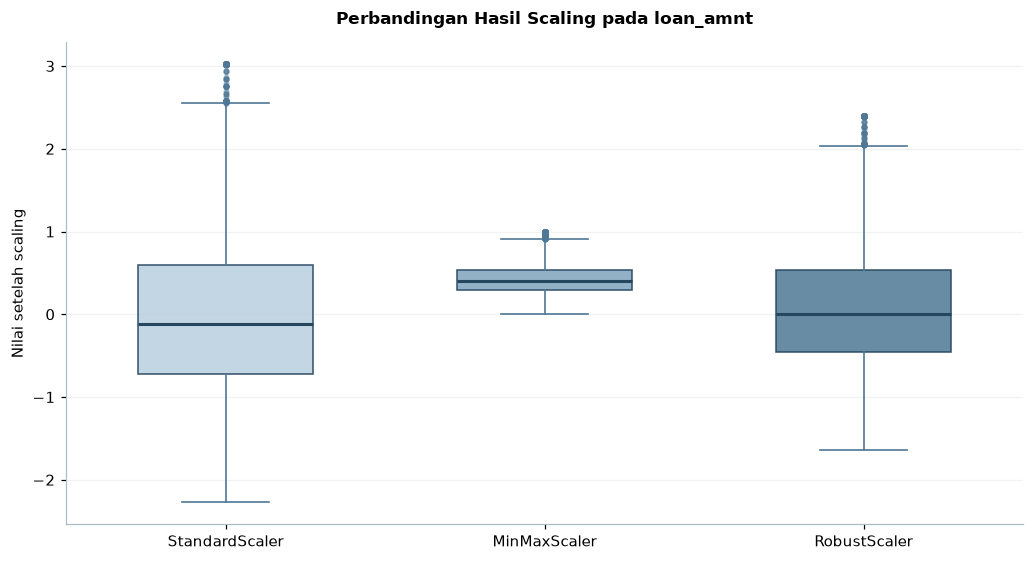

In [33]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))

box = ax.boxplot(
    [
        scaled_examples["StandardScaler"],
        scaled_examples["MinMaxScaler"],
        scaled_examples["RobustScaler"]
    ],
    tick_labels=["StandardScaler", "MinMaxScaler", "RobustScaler"],
    patch_artist=True,
    widths=0.55,
    showfliers=True,
    boxprops=dict(edgecolor=COLOR_DARK, linewidth=1.1),
    medianprops=dict(color=COLOR_DARK, linewidth=2),
    whiskerprops=dict(color=COLOR_PRIMARY, linewidth=1.1),
    capprops=dict(color=COLOR_PRIMARY, linewidth=1.1),
    flierprops=dict(
        marker="o",
        markersize=3,
        markerfacecolor=COLOR_PRIMARY,
        markeredgecolor=COLOR_PRIMARY,
        alpha=0.35
    )
)

box_colors = [COLOR_LIGHT, COLOR_MID, COLOR_PRIMARY]
for patch, color in zip(box["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.set_title(
    f"Perbandingan Hasil Scaling pada {scale_example_col}",
    pad=12,
    weight="bold"
)
ax.set_ylabel("Nilai setelah scaling")
ax.grid(axis="y", alpha=0.16)

plt.tight_layout()
plt.show()


<div style="text-align: justify; line-height: 1.65;">Visualisasi memperlihatkan bahwa ketiga scaler mempertahankan urutan observasi, tetapi pusat dan rentang akhirnya berbeda. RobustScaler menempatkan median tepat di 0 dan tetap menampilkan observasi ekstrem tanpa menjadikannya penentu utama pusat serta skala. Pola tersebut mendukung pemilihan RobustScaler sebagai baseline untuk model yang membutuhkan scaling.</div>


## **13.2 Treatment Final RobustScaler**


In [34]:
excluded_from_scaling = [
    "cb_person_default_on_file",
    "loan_grade",
    *ohe_cols.tolist()
]

scale_cols = [
    col for col in X_train_encoded.columns
    if col not in excluded_from_scaling
]

scaler = RobustScaler()

X_train_final = X_train_encoded.copy()
X_val_final = X_val_encoded.copy()
X_test_final = X_test_encoded.copy()

X_train_final[scale_cols] = scaler.fit_transform(X_train_encoded[scale_cols])
X_val_final[scale_cols] = scaler.transform(X_val_encoded[scale_cols])
X_test_final[scale_cols] = scaler.transform(X_test_encoded[scale_cols])

print("Jumlah fitur yang di scale:", len(scale_cols))
print("Fitur yang tidak di scale:", excluded_from_scaling)
display(X_train_final.head())


Jumlah fitur yang di scale: 9
Fitur yang tidak di scale: ['cb_person_default_on_file', 'loan_grade', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']


,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,interest_burden_proxy,employment_age_ratio,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
7126,-0.142857,-0.086201,0.811993,3,-0.642769,1.075444,-0.581656,0,0.000000,-0.250159,1.028105,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
15645,-0.571429,0.682680,0.191686,1,0.810461,0.101418,0.139279,0,0.000000,0.665995,0.383987,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
7626,-0.285714,0.735567,-0.475654,2,-0.231685,0.478041,-0.683378,1,-0.275170,0.009014,-0.314542,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
20390,0.142857,-0.154479,0.000000,2,-0.494659,0.785401,-0.395753,0,0.579586,-0.162588,0.000000,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
7969,-0.428571,-0.160125,0.524346,3,-0.459606,0.906613,-0.395753,0,-0.629926,-0.090216,0.758028,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


<div style="text-align: justify; line-height: 1.65;">RobustScaler diterapkan pada 9 fitur numerik kontinu dan fitur hasil feature engineering. Fitur biner, <code>loan_grade</code>, serta 10 indikator One Hot Encoding tidak ikut di scale agar representasi kategorinya tetap mudah dibaca. Hasil contoh training menunjukkan fitur yang di scale sudah berada pada skala yang lebih sebanding, sedangkan kolom kategorikal tetap mempertahankan nilai aslinya.</div>


## **14. Final Preprocessing Validation**


In [35]:
def final_check(name, X_split):
    return {
        "subset": name,
        "baris": X_split.shape[0],
        "fitur": X_split.shape[1],
        "missing": int(X_split.isna().sum().sum()),
        "infinity": int(np.isinf(X_split.to_numpy(dtype=float)).sum()),
        "kolom_non_numeric": len(X_split.select_dtypes(exclude=np.number).columns),
        "target_ada_di_X": TARGET in X_split.columns
    }

final_validation = pd.DataFrame([
    final_check("Train", X_train_final),
    final_check("Validation", X_val_final),
    final_check("Test", X_test_final)
])

display(final_validation)

print("Kolom train sama dengan validation:", X_train_final.columns.equals(X_val_final.columns))
print("Kolom train sama dengan test:", X_train_final.columns.equals(X_test_final.columns))


,subset,baris,fitur,missing,infinity,kolom_non_numeric,target_ada_di_X
0,Train,22691,21,0,0,0,False
1,Validation,4862,21,0,0,0,False
2,Test,4863,21,0,0,0,False


Kolom train sama dengan validation: True
Kolom train sama dengan test: True


<div style="text-align: justify; line-height: 1.65;">Final validation menunjukkan 22.691 baris training, 4.862 validation, dan 4.863 test dengan 21 predictor pada setiap subset. Missing value dan infinity sama sama 0, seluruh predictor sudah numerik, target tidak berada di dalam X, serta struktur kolom validation dan test sama dengan training. Hasil ini menunjukkan bahwa data sudah konsisten secara teknis untuk masuk ke tahap modeling.</div>


## **14.1 Ringkasan Kondisi Sebelum dan Sesudah Preprocessing**


In [36]:
before_after = pd.DataFrame({
    "indikator": [
        "Jumlah baris",
        "Jumlah predictor",
        "Total missing",
        "Jumlah predictor non numeric"
    ],
    "sebelum": [
        len(df),
        df.drop(columns=[TARGET]).shape[1],
        int(df.drop(columns=[TARGET]).isna().sum().sum()),
        len(df.drop(columns=[TARGET]).select_dtypes(exclude=np.number).columns)
    ],
    "sesudah_train": [
        len(X_train_final),
        X_train_final.shape[1],
        int(X_train_final.isna().sum().sum()),
        len(X_train_final.select_dtypes(exclude=np.number).columns)
    ]
})

display(before_after)


,indikator,sebelum,sesudah_train
0,Jumlah baris,32581,22691
1,Jumlah predictor,11,21
2,Total missing,4011,0
3,Jumlah predictor non numeric,4,0


<div style="text-align: justify; line-height: 1.65;">Pipeline mengubah 11 predictor awal menjadi 21 predictor pada training setelah feature engineering dan encoding. Total missing turun dari 4.011 pada data mentah menjadi 0 pada hasil training, sedangkan jumlah predictor non numerik turun dari 4 menjadi 0. Jumlah baris training sebesar 22.691 merupakan hasil split, bukan akibat penghapusan observasi setelah split.</div>


## **15. Export Processed Data**


In [37]:
train_processed = X_train_final.copy()
train_processed[TARGET] = y_train.values

val_processed = X_val_final.copy()
val_processed[TARGET] = y_val.values

test_processed = X_test_final.copy()
test_processed[TARGET] = y_test.values

train_processed.to_csv("credit_train_processed.csv", index=False)
val_processed.to_csv("credit_validation_processed.csv", index=False)
test_processed.to_csv("credit_test_processed.csv", index=False)

print("File berhasil dibuat:")
print("credit_train_processed.csv")
print("credit_validation_processed.csv")
print("credit_test_processed.csv")


File berhasil dibuat:
credit_train_processed.csv
credit_validation_processed.csv
credit_test_processed.csv


<div style="text-align: justify; line-height: 1.65;">Tiga file processed berhasil dibuat untuk training, validation, dan test. Seluruh file menggunakan keputusan preprocessing dan parameter yang sama, sedangkan proses fit hanya dilakukan pada training. Struktur ini membuat ketiga file siap digunakan pada tahap modeling tanpa mengulang preprocessing.</div>


## **16. Ringkasan Treatment Final**


<div style="text-align: justify; line-height: 1.65;">
<table style="border-collapse: collapse; width: 100%;">
<tr><th style="text-align: left; padding: 6px;">Tahap</th><th style="text-align: left; padding: 6px;">Treatment final</th></tr>
<tr><td style="padding: 6px;">Exact duplicate</td><td style="padding: 6px;">165 record identik dihapus sebelum split</td></tr>
<tr><td style="padding: 6px;">Domain validation</td><td style="padding: 6px;">Nilai yang melanggar aturan domain diubah menjadi missing value. Usia di atas 100 tahun digunakan sebagai asumsi domain pada latihan ini</td></tr>
<tr><td style="padding: 6px;">Outlier</td><td style="padding: 6px;">Boxplot dan IQR digunakan untuk deteksi kandidat. Valid extreme values tetap dipertahankan</td></tr>
<tr><td style="padding: 6px;">Missing value</td><td style="padding: 6px;"><code>person_age</code> menggunakan median, <code>person_emp_length</code> menggunakan median, dan <code>loan_int_rate</code> menggunakan mean</td></tr>
<tr><td style="padding: 6px;">Feature engineering</td><td style="padding: 6px;"><code>interest_burden_proxy</code> dan <code>employment_age_ratio</code></td></tr>
<tr><td style="padding: 6px;">Skewness</td><td style="padding: 6px;">Log1p untuk <code>person_income</code>, <code>interest_burden_proxy</code>, dan <code>cb_person_cred_hist_length</code>. Square root untuk <code>loan_amnt</code>, <code>loan_percent_income</code>, dan <code>person_emp_length</code>. <code>person_age</code> tetap original</td></tr>
<tr><td style="padding: 6px;">Binary categorical</td><td style="padding: 6px;">Binary mapping</td></tr>
<tr><td style="padding: 6px;">Ordinal categorical</td><td style="padding: 6px;">Ordinal mapping</td></tr>
<tr><td style="padding: 6px;">Nominal categorical</td><td style="padding: 6px;">One Hot Encoding dengan <code>handle_unknown="ignore"</code></td></tr>
<tr><td style="padding: 6px;">Scaling</td><td style="padding: 6px;">RobustScaler untuk baseline model yang membutuhkan scaling. Data sebelum scaling tetap tersedia untuk model berbasis tree</td></tr>
<tr><td style="padding: 6px;">Final validation</td><td style="padding: 6px;">Missing dan infinity bernilai 0, seluruh predictor numerik, target tidak berada di X, serta struktur kolom sama pada seluruh subset</td></tr>
</table>
</div>


<div style="text-align: justify; line-height: 1.65;">Pipeline final tidak bertujuan memakai seluruh metode preprocessing. Setiap metode dipilih setelah karakteristik data diperiksa dan dibandingkan. Struktur ini membantu peserta memahami bahwa preprocessing merupakan proses pengambilan keputusan, bukan urutan fungsi yang selalu sama untuk seluruh dataset.</div>


## **17. Mini Assignment**


<div style="text-align: justify; line-height: 1.65;"><b>Feature Selection</b><br>Peserta dapat mengevaluasi apakah seluruh predictor final perlu digunakan atau terdapat fitur yang redundant maupun kurang informatif.<br><br><b>Class Imbalance Handling</b><br>Peserta dapat membandingkan class weight, random oversampling, random undersampling, dan SMOTE. Resampling hanya dilakukan pada training data agar validation dan test tetap merepresentasikan distribusi data asli.</div>
